# Lab 1 Task 1

## 1. Implement the following layers as Python functions (both forward and backward propagation)
* Inner-product layer
* Activation layer(Sigmoid or Rectified)
* Softmax layer

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/2025_EAI

/content/drive/MyDrive/2025_EAI


In [ ]:
import os
from typing import Callable, Iterable
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

In [ ]:
class Parameter:
    def __init__(self, data: np.ndarray) -> None:
        self.data = data
        self.grad = None


class Module:
    def __call__(self, *args, **kwargs) -> np.ndarray:
        return self.forward(*args, **kwargs)

    def __repr__(self) -> str:
        layers = '\n'.join([f'  ({k}): {v}' for k, v in self.__dict__.items()])
        return f'{self.__class__.__name__}(\n{layers}\n)'

In [ ]:
class Linear(Module):
    def __init__(self, in_features, out_features) -> None:
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features

        # Initialize weights and biases
        init_factor = 0.01
        self.W = Parameter(np.random.randn(in_features, out_features) * init_factor)
        self.b = Parameter(np.zeros((1, out_features)))

        # Cache for backward pass
        self.x = None

    def forward(self, x):
        # 學生實作部分：reutrn output of linear layer
        # Forward pass: y = xW + b
        # x: (N * in_features)
        # W: (in_features * out_features)
        # b: (1 * out_features)
        # return: (N * out_features)

        self.x = x
        output = np.dot(x, self.W.data) + self.b.data
        return output

    def backward(self, dy):
        # 學生實作部分：return gradient w.r.t. input and compute gradients for weights and biases
        # 學生實作部分：return gradient w.r.t. input and compute gradients for weights and biases
        # dy: (N * out_features) 上游傳來的梯度
        # return: dx  (N * in_features)
        # 更新 self.W.grad, self.b.grad

        dx = np.dot(dy, self.W.data.T) #dEdx = dy @ W^T
        self.W.grad = np.dot(self.x.T, dy) # dEdW = x^T @ dy
        self.b.grad = np.sum(dy, axis=0, keepdims=True) # dEdb = sum(dy, axis=0) -> keepdims 保持形狀 (1 * out_features)
        return dx

    def parameters(self):
        return self.W, self.b

    def __repr__(self) -> str:
        return f'{self.__class__.__name__}(in_features={self.in_features}, out_features={self.out_features})'


class ReLU(Module):
    def __init__(self) -> None:
        super().__init__()
        self.x = None

    def forward(self, x):
        # 學生實作部分：return output of ReLU activation
        self.x = x
        return np.maximum(0, x)

    def backward(self, dy):
        # 學生實作部分：return gradient w.r.t. input
        dEdx = dy * (self.x > 0)
        return dEdx

    def __repr__(self) -> str:
        return f'{self.__class__.__name__}()'


class Sigmoid(Module):
    def __init__(self) -> None:
        super().__init__()
        self.y = None

    def forward(self, x):
        # 學生實作部分：return output of Sigmoid activation
        self.out = 1 / (1 + np.exp(-x))
        return self.out

    def backward(self, dy):
        # 學生實作部分：return gradient w.r.t. input
        dEdx = dy * self.out * (1 - self.out)
        return dEdx


    def __repr__(self) -> str:
        return f'{self.__class__.__name__}()'


class Softmax(Module):
    def __init__(self) -> None:
        super().__init__()
        self.y = None

    def forward(self, x):
        # 學生實作部分：return output of Softmax activation
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))  # 防 overflow
        self.out = exp_x / np.sum(exp_x, axis=1, keepdims=True)
        return self.out

    def backward(self, dy):
        # 這邊我們設定同學們會將Softmax和Cross-Entropy Loss一起使用
        # 因此backward pass根據講義上的說明使用簡化的版本在Cross-Entropy Loss的部分完成
        # 若同學的softmax沒有和Cross-Entropy Loss一起使用，請自行實作完整的backward pass
        return dy

    def __repr__(self) -> str:
        return f'{self.__class__.__name__}()'

In [ ]:
#整體模型運算（組合多層）
#都先不寫softmax的部分，因為這樣能保有數值穩定性，之後再與CrossEntrophy那邊串接起就好
class MLP(Module):
    def __init__(self) -> None:
        # 學生實作部分：design your Model architecture here
        super().__init__()
        self.fc1 = Linear(784, 128) # Linear(input_dim, hidden_dim)
        self.relu = ReLU()
        self.fc2 = Linear(128, 10) # Linear(hidden_dim, output_dim)

    def forward(self, x):
        # 學生實作部分：compute forward pass through your model
        I_H_out = self.fc1(x)
        activate_out = self.relu(I_H_out)
        H_O_out = self.fc2(activate_out)
        return H_O_out

    def backward(self, dy):
        # 學生實作部分：compute backward pass through your model
        # 少crossentrophy的backward
        O_H_grad = self.fc2.backward(dy)
        activate_grad = self.relu.backward(O_H_grad)
        H_I_grad = self.fc1.backward(activate_grad)
        return H_I_grad

    def parameters(self):
        return self.fc1.parameters() + self.fc2.parameters()


## 2. Implement training and testing process
* included cross-validation

In [ ]:
class MNIST:
    # root請根據你的檔案位置更改
    def __init__(self, root='../data', train=True, transform: Callable = None) -> None:
        path = os.path.join(root, 'mnist_train.csv' if train else 'mnist_test.csv')
        self.data = np.loadtxt(path, delimiter=',')
        self.transform = transform
        self.image_size = 28
        self.num_classes = 10
        self.classes = np.arange(self.num_classes)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        label = (self.data[idx, 0] == self.classes).astype(
            np.float32
        )  # one-hot encoding
        image = (
            self.data[idx, 1:]
            .reshape(self.image_size * self.image_size)
            .astype(np.float32)
        )
        if self.transform:
            image = self.transform(image)
        return image, label


class Subset:
    def __init__(self, dataset, indices: Iterable) -> None:
        self.dataset = dataset
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        return self.dataset[self.indices[idx]]


class DataLoader:
    def __init__(self, dataset, batch_size=1) -> None:
        self.dataset = dataset
        self.batch_size = batch_size
        self.indices = np.arange(len(dataset))

    def __len__(self):
        return (len(self.dataset) + self.batch_size - 1) // self.batch_size

    def __iter__(self):
        for start_idx in range(0, len(self.dataset), self.batch_size):
            end_idx = min(start_idx + self.batch_size, len(self.dataset))
            batch_indices = self.indices[start_idx:end_idx]

            batch_images = []
            batch_labels = []

            for idx in batch_indices:
                image, label = self.dataset[idx]
                batch_images.append(image)
                batch_labels.append(label)

            yield np.array(batch_images), np.array(batch_labels)

In [ ]:

# Separate train_imgs, train_labels into training and validation
# root請根據你的檔案位置更改
def load_mnist_data(
    root="/content/drive/MyDrive/2025_EAI", batch_size=1, split_ratio=0.1, transform=None
) -> tuple[DataLoader, DataLoader, DataLoader]:
    def _split_dataset(dataset, split_ratio):
        # 學生實作部分：split dataset into training and validation sets
        # hint: return Subset(dataset, train_indices), Subset(dataset, valid_indices)

        total_len = len(dataset)
        indices = np.arange(total_len)
        np.random.shuffle(indices)

        split_index = int(total_len * (1 - split_ratio))
        train_indices = indices[:split_index]
        valid_indices = indices[split_index:]

        return Subset(dataset, train_indices), Subset(dataset, valid_indices)


    trainset = MNIST(root=root, train=True, transform=transform)
    testset = MNIST(root=root, train=False, transform=transform)
    trainset, validset = _split_dataset(trainset, split_ratio=split_ratio)
    trainldr = DataLoader(trainset, batch_size=batch_size)
    validldr = DataLoader(validset, batch_size=batch_size)
    testldr = DataLoader(testset, batch_size=batch_size)
    return trainldr, validldr, testldr


In [ ]:
class CrossEntropyLoss(Module):
    def __init__(self, epsilon=1e-15) -> None:
        super().__init__()
        self.epsilon = epsilon  # small value to avoid log(0)
        self.y_pred = None
        self.y_true = None

    def forward(self, y_pred, y_true):
        self.y_pred = np.clip(y_pred, self.epsilon, 1 - self.epsilon)
        self.y_true = y_true
        batch_size = y_true.shape[0]
        loss = -np.sum(y_true * np.log(self.y_pred)) / batch_size
        return loss

    def backward(self):
        batch_size = self.y_true.shape[0]
        grad = (self.y_pred - self.y_true) / batch_size
        return grad

    def __repr__(self) -> str:
        return f"{self.__class__.__name__}()"


class SGD:
    def __init__(self, params: Iterable, lr: float = 1e-3) -> None:
        self.params = params
        self.lr = lr

    def step(self):
        for param in self.params:
            if param.grad is not None:
                param.data -= self.lr * param.grad

    def zero_grad(self):
        for param in self.params:
            if param.grad is not None:
                param.grad.fill(0)

In [ ]:
def train_one_epoch(model: Module, trainldr: Iterable, criterion, optimizer) -> tuple[float, float]:
    total = 0
    correct = 0
    total_loss = 0
    for x, y in tqdm(trainldr):
        # 學生實作部分：complete the training process through one epoch
        x = x.reshape(x.shape[0], -1)  # ← 攤平成 1D

        if y.ndim == 1:
            y = np.eye(10)[y]  # one-hot encoding
        # Hint:
        # 1. forward propagation
        y_pred = model.forward(x)
        #y_prob = np.exp(y_pred) / np.sum(np.exp(y_pred), axis=1, keepdims=True)  # softmax # (batch_size, num_classes)

        y_prob = np.exp(y_pred - np.max(y_pred, axis=1, keepdims=True))  # softmax with stability
        y_prob /= np.sum(y_prob, axis=1, keepdims=True)

        # 2. compute loss
        loss = criterion.forward(y_prob, y)

        # 3. compute accuracy
        pred_labels = np.argmax(y_prob, axis=1)  # 把機率轉成實際的「預測類別」與「真實類別」
        true_labels = np.argmax(y, axis=1) # 回傳最大值的索引（也就是機率最大的那一類） # 沿著「每一列」找最大值（也就是對每張圖片）
        correct += np.sum(pred_labels == true_labels)
        total += len(y)

        # 4. backward propagation
        dy = criterion.backward()
        model.backward(dy)

        # 5. update parameters
        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


def evaluate(model: Module, testldr: Iterable) -> tuple[float, float]:
    total = 0
    correct = 0
    total_loss = 0
    criterion = CrossEntropyLoss()  # separate criterion from training
    for x, y in tqdm(testldr):
        # 學生實作部分：complete the evaluation process
        x = x.reshape(x.shape[0], -1)  # ← 攤平成 1D

        # one hot decode
        if y.ndim == 1:
            y = np.eye(10)[y]

        # Hint:
        # 1. forward propagation
        y_pred = model.forward(x)  # logits
        exp_x = np.exp(y_pred - np.max(y_pred, axis=1, keepdims=True))  # softmax for probability
        y_prob = exp_x / np.sum(exp_x, axis=1, keepdims=True)

        # 2. compute total loss
        loss = criterion.forward(y_prob, y)

        # 3. compute correct and total
        pred_labels = np.argmax(y_prob, axis=1)
        true_labels = np.argmax(y, axis=1)
        correct += np.sum(pred_labels == true_labels)
        total += len(y)

        total_loss += loss

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


def train(model: MLP, trainldr: Iterable, validldr: Iterable, epochs=10, lr=1e-3):
    criterion = CrossEntropyLoss()
    # 這邊提供SGD作為optimizer，同學也可以根據自己人需求更換其他optimizer
    optimizer = SGD(model.parameters(), lr=lr)
    train_loss = []
    train_acc = []
    valid_loss = []
    valid_acc = []

    for epoch in range(epochs):
        loss, acc = train_one_epoch(model, trainldr, criterion, optimizer)
        train_loss.append(loss)
        train_acc.append(acc)
        print(f'epoch {epoch:d}: train_loss = {loss}, train_acc = {acc}')

        loss, acc = evaluate(model, validldr)
        valid_loss.append(loss)
        valid_acc.append(acc)
        print(f'epoch {epoch:d}: valid_loss = {loss}, valid_acc = {acc}\n')

    return train_loss, train_acc, valid_loss, valid_acc

In [ ]:
def transform(x):
    """map pixels information from range(0, 255) to range(0.01, 1)"""
    #return np.asarray(x) * 0.99 + 0.01 #怪怪的
    x = np.asarray(x) / 255.0  # 0~1
    return x * 0.99 + 0.01     # 0.01~1.0

# "../data"請根據你的檔案位置更改
trainldr, validldr, testldr = load_mnist_data(
    "/content/drive/MyDrive/2025_EAI", batch_size=64, transform=transform
)
print(f"train set: {len(trainldr)} images")
print(f"validation set: {len(validldr)} images")
print(f"test set: {len(testldr)} images")
for x, y in trainldr:
    print(f"x shape: {x.shape}")
    print(f"y shape: {y.shape}")
    break

net = MLP()
print(net)
# 你可以調整 epochs 和 lr 來觀察不同的訓練效果
train_loss, train_acc, valid_loss, valid_acc = train(
    net, trainldr, validldr, epochs=10, lr=1e-2
)

train set: 844 images
validation set: 94 images
test set: 157 images
x shape: (64, 784)
y shape: (64, 10)
MLP(
  (fc1): Linear(in_features=784, out_features=128)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=10)
)


100%|██████████| 844/844 [00:04<00:00, 183.80it/s]


epoch 0: train_loss = 0.030647703560025094, train_acc = 0.5632407407407407


100%|██████████| 94/94 [00:00<00:00, 163.09it/s]


epoch 0: valid_loss = 0.018657488271719126, valid_acc = 0.7298333333333333



...

epoch 8: valid_loss = 0.004641746521289025, valid_acc = 0.9141666666666667



100%|██████████| 844/844 [00:04<00:00, 191.35it/s]


epoch 9: train_loss = 0.004546648589514095, train_acc = 0.9173333333333333


100%|██████████| 94/94 [00:00<00:00, 323.62it/s]

epoch 9: valid_loss = 0.00448839976674141, valid_acc = 0.9168333333333333



In [ ]:
# Using test_images and test_labels to do the final test
test_loss, test_acc = evaluate(net, testldr)
print(f"test_loss = {test_loss}, test_acc = {test_acc}")

100%|██████████| 157/157 [00:00<00:00, 365.28it/s]

test_loss = 0.004319286697338523, test_acc = 0.9219


## 3. Plot loss & accuracy curves(both Training and Validation)

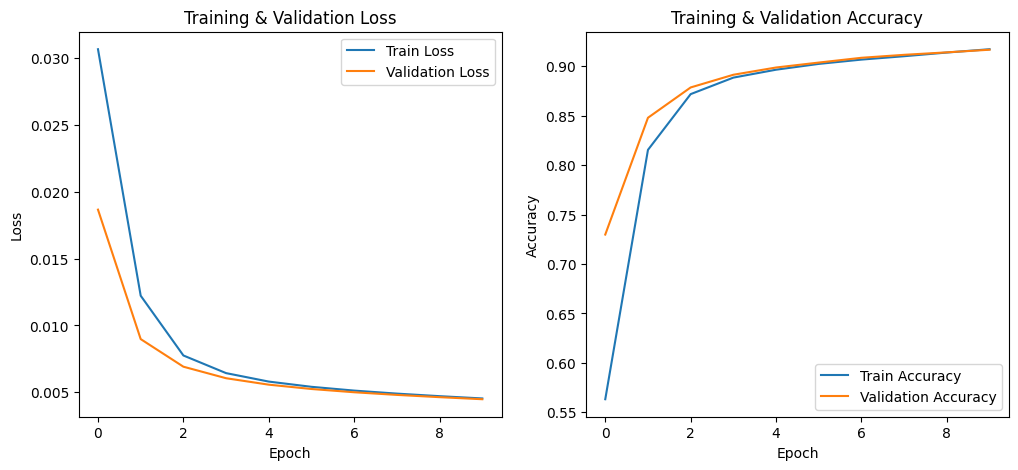

In [ ]:
# Plot training and validation loss and accuracy curves

plt.figure(figsize=(12, 5))

# Loss 曲線
plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Train Loss')
plt.plot(valid_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()

# Accuracy 曲線
plt.subplot(1, 2, 2)
plt.plot(train_acc, label='Train Accuracy')
plt.plot(valid_acc, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy')
plt.legend()

plt.show()